# Часть 1

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.0 MB/s eta 0:00:00


In [ ]:
# Импорт библиотек
import spacy
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from spacy.lang.en.stop_words import STOP_WORDS
from gensim.models import Word2Vec
from gensim.models.doc2vec import TaggedDocument
from torch.utils.data import DataLoader, Dataset, random_split
from datasets import Dataset as HFDataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    BertForSequenceClassification,
    pipeline
)

In [ ]:
# Тексты песен
let_it_be = """
When I find myself in times of trouble, Mother Mary comes to me
Speaking words of wisdom, let it be
And in my hour of darkness she is standing right in front of me
Speaking words of wisdom, let it be
Let it be, let it be, let it be, let it be
Whisper words of wisdom, let it be
And when the broken hearted people living in the world agree
There will be an answer, let it be
For though they may be parted, there is still a chance that they will see
There will be an answer, let it be
Let it be, let it be, let it be, let it be
There will be an answer, let it be
Let it be, let it be, let it be, let it be
Whisper words of wisdom, let it be
Let it be, let it be, let it be, let it be
Whisper words of wisdom, let it be, be
And when the night is cloudy there is still a light that shines on me
Shinin' until tomorrow, let it be
I wake up to the sound of music, Mother Mary comes to me
Speaking words of wisdom, let it be
And let it be, let it be, let it be, let it be
Whisper words of wisdom, let it be
And let it be, let it be, let it be, let it be
Whisper words of wisdom, let it be
"""
jingle_bells = """Dashing through the snow
In a one-horse open sleigh,
Over the fields we go,
Laughing all the way;
The bells on bob-tail ring,
They make our spirits bright,
What fun it is to ride and sing
A sleighing song tonight, O
Jingle bells, jingle bells,
Jingle all the way!
O what fun it is to ride
In a one-horse open sleigh
Jingle bells, jingle bells,
Jingle all the way!
O what fun it is to ride
In a one-horse open sleigh
A day or two ago,
I thought I’d take a ride,
And soon Miss Fanny Bright
Was seated by my side;
The horse was lean and lank;
Misfortune seemed his lot;
He got into a drifted bank,
And we, we got upset. O
Jingle bells, jingle bells,
Jingle all the way!
O what fun it is to ride
In a one-horse open sleigh
Jingle bells, jingle bells,
Jingle all the way!
O what fun it is to ride
In a one-horse open sleigh
Now the ground is white
So go it while you’re young,
Take the girls tonight
And sing this sleighing song;
Just get a bob-tailed nag
Two-forty for his speed
Then hitch him to an open sleigh
And crack! you’ll take the lead, O
Jingle bells, jingle bells,
Jingle all the way!
O what fun it is to ride
In a one-horse open sleigh
Jingle bells, jingle bells,
Jingle all the way!
O what fun it is to ride
In a one-horse open sleigh"""

smells_like_teen_spirit = """Load up on guns, bring your friends
It's fun to lose and to pretend
She's over-bored and self assured
Oh no, I know a dirty word
Hello, hello, hello, how low
Hello, hello, hello, how low
Hello, hello, hello, how low
Hello, hello, hello
With the lights out, it's less dangerous
Here we are now, entertain us
I feel stupid and contagious
Here we are now, entertain us
A mulatto, an albino, a mosquito, my libido
Yeah, hey, yay
I'm worse at what I do best
And for this gift I feel blessed
Our little group has always been
And always will until the end
Hello, hello, hello, how low
Hello, hello, hello, how low
Hello, hello, hello, how low
Hello, hello, hello
With the lights out, it's less dangerous
Here we are now, entertain us
I feel stupid and contagious
Here we are now, entertain us
A mulatto, an albino, a mosquito, my libido
Yeah, hey, yay
And I forget just why I taste
Oh yeah, I guess it makes me smile
I found it hard, it's hard to find
Oh well, whatever, never mind
Hello, hello, hello, how low
Hello, hello, hello, how low
Hello, hello, hello, how low
Hello, hello, hello
With the lights out, it's less dangerous
Here we are now, entertain us
I feel stupid and contagious
Here we are now, entertain us
A mulatto, an albino, a mosquito, my libido
A denial, a denial, a denial, a denial, a denial
A denial, a denial, a denial, a denial"""

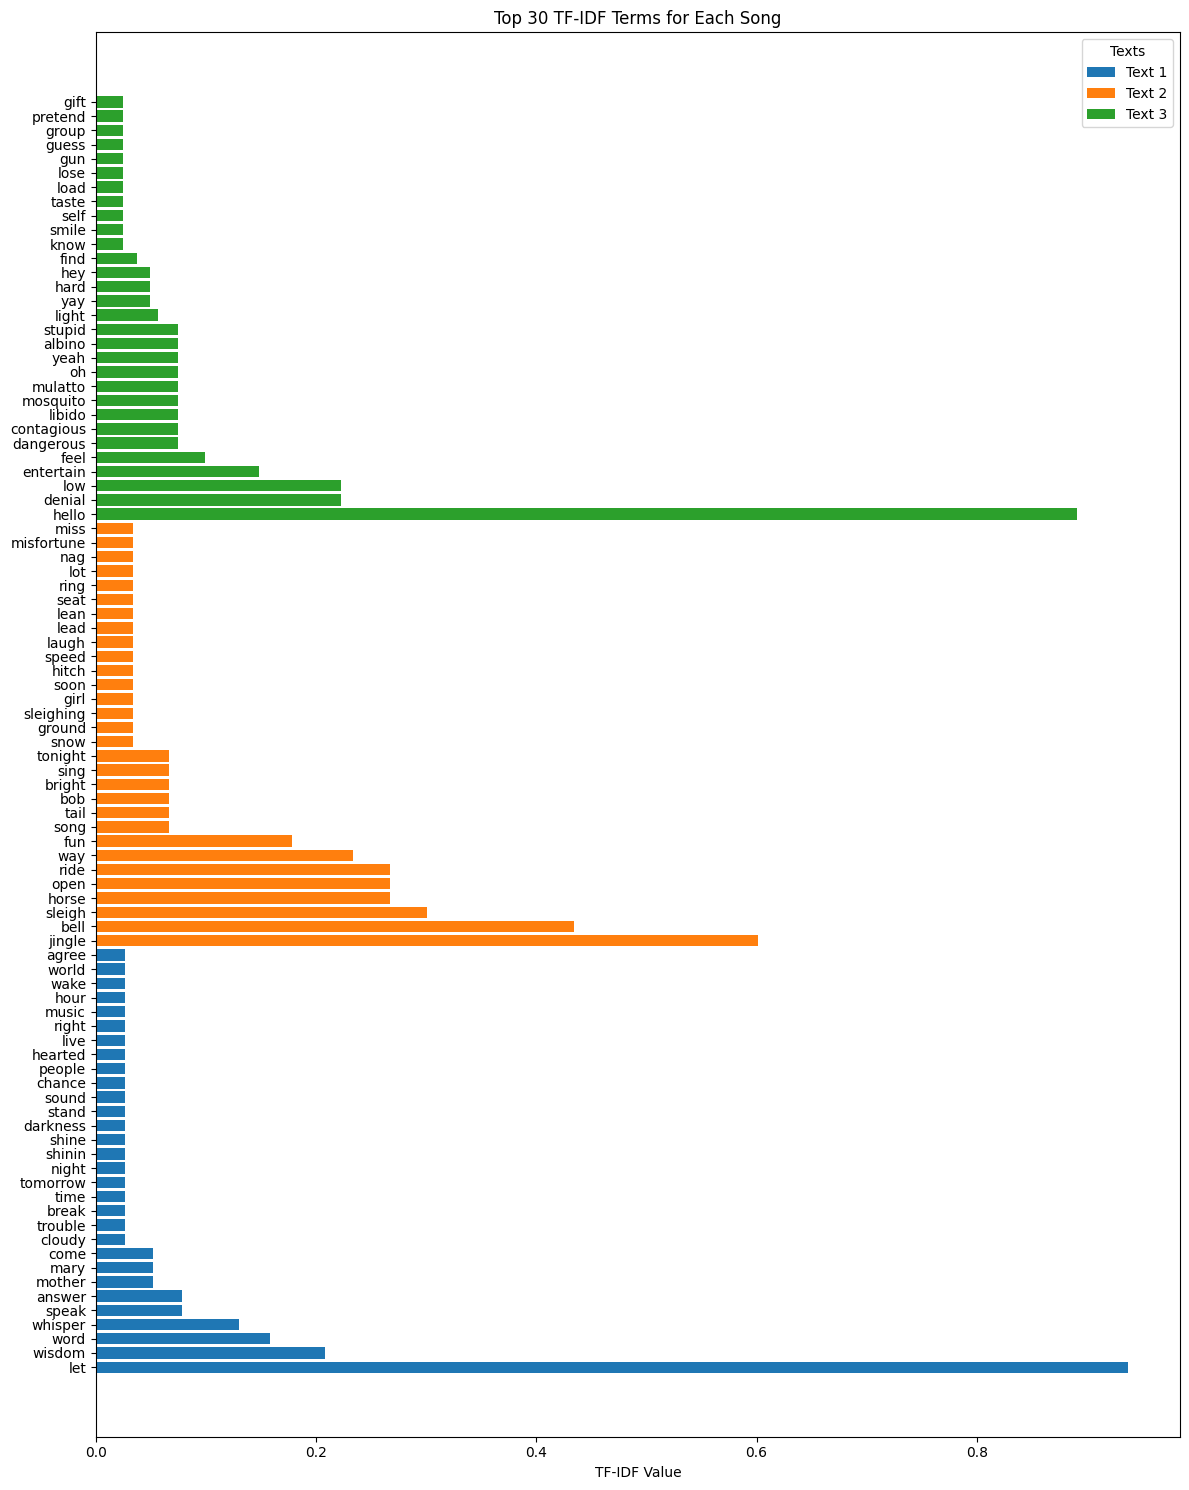

In [ ]:
# Для английского языка
nlp = spacy.load("en_core_web_sm")

def lemmatize_and_remove_stopwords(text):
    doc = nlp(text)
    return ' '.join([token.lemma_ for token in doc if token.lemma_ not in STOP_WORDS])

# Применение лемматизации и удаления стоп-слов к текстам песен
texts = [let_it_be, jingle_bells, smells_like_teen_spirit]
processed_texts = [lemmatize_and_remove_stopwords(text) for text in texts]

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(processed_texts)
terms = vectorizer.get_feature_names_out()
tfidf_values = tfidf_matrix.toarray()
tfidf_df = pd.DataFrame(tfidf_values, columns=terms)

plt.figure(figsize=(12, 15))

for i, text in enumerate(processed_texts):
    # Выбираем топ 30 слов по значениям TF-IDF
    top_terms = tfidf_df.iloc[i].sort_values(ascending=False).head(30)
    plt.barh(top_terms.index, top_terms.values, label=f"Text {i+1}")

plt.xlabel('TF-IDF Value')
plt.title('Top 30 TF-IDF Terms for Each Song')
plt.legend(title="Texts")
plt.tight_layout()
plt.show()

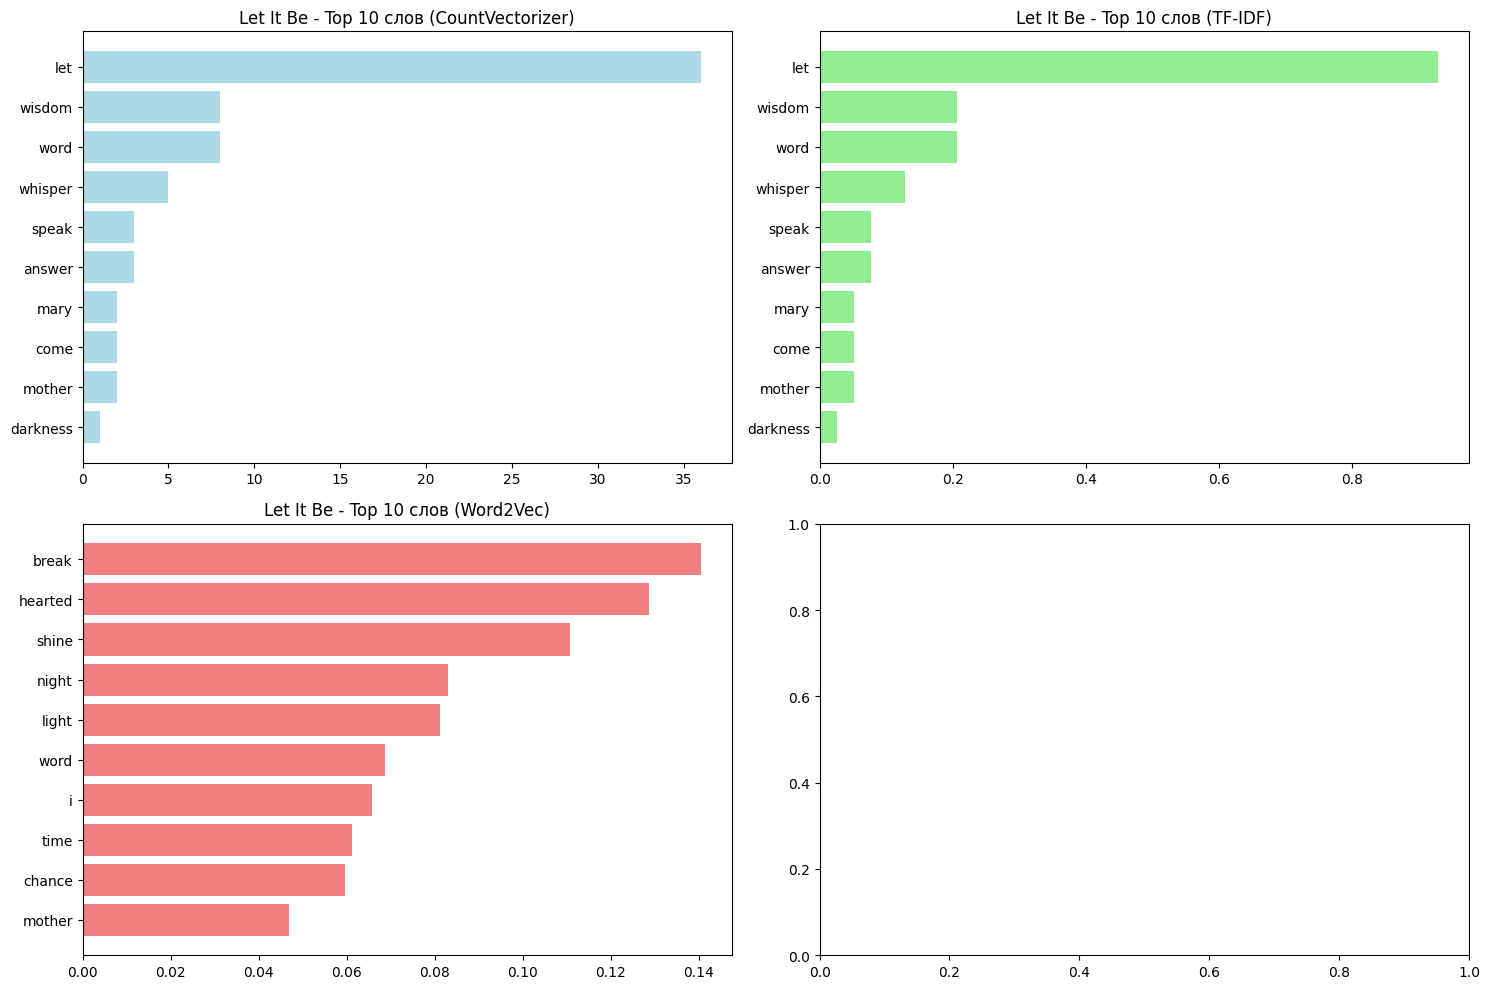

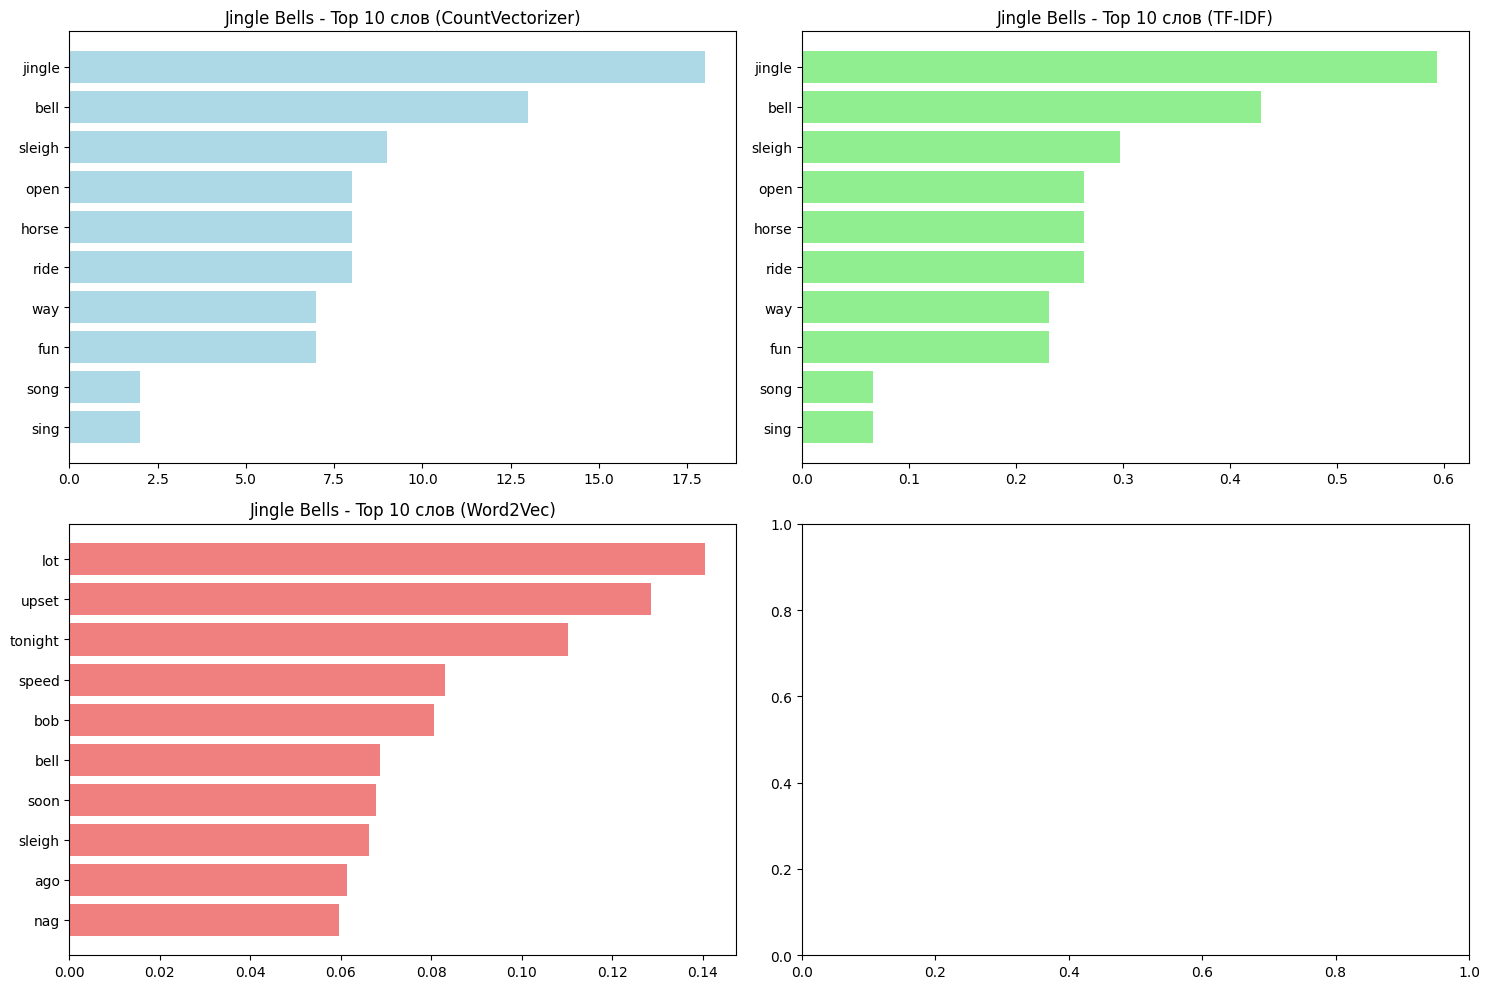

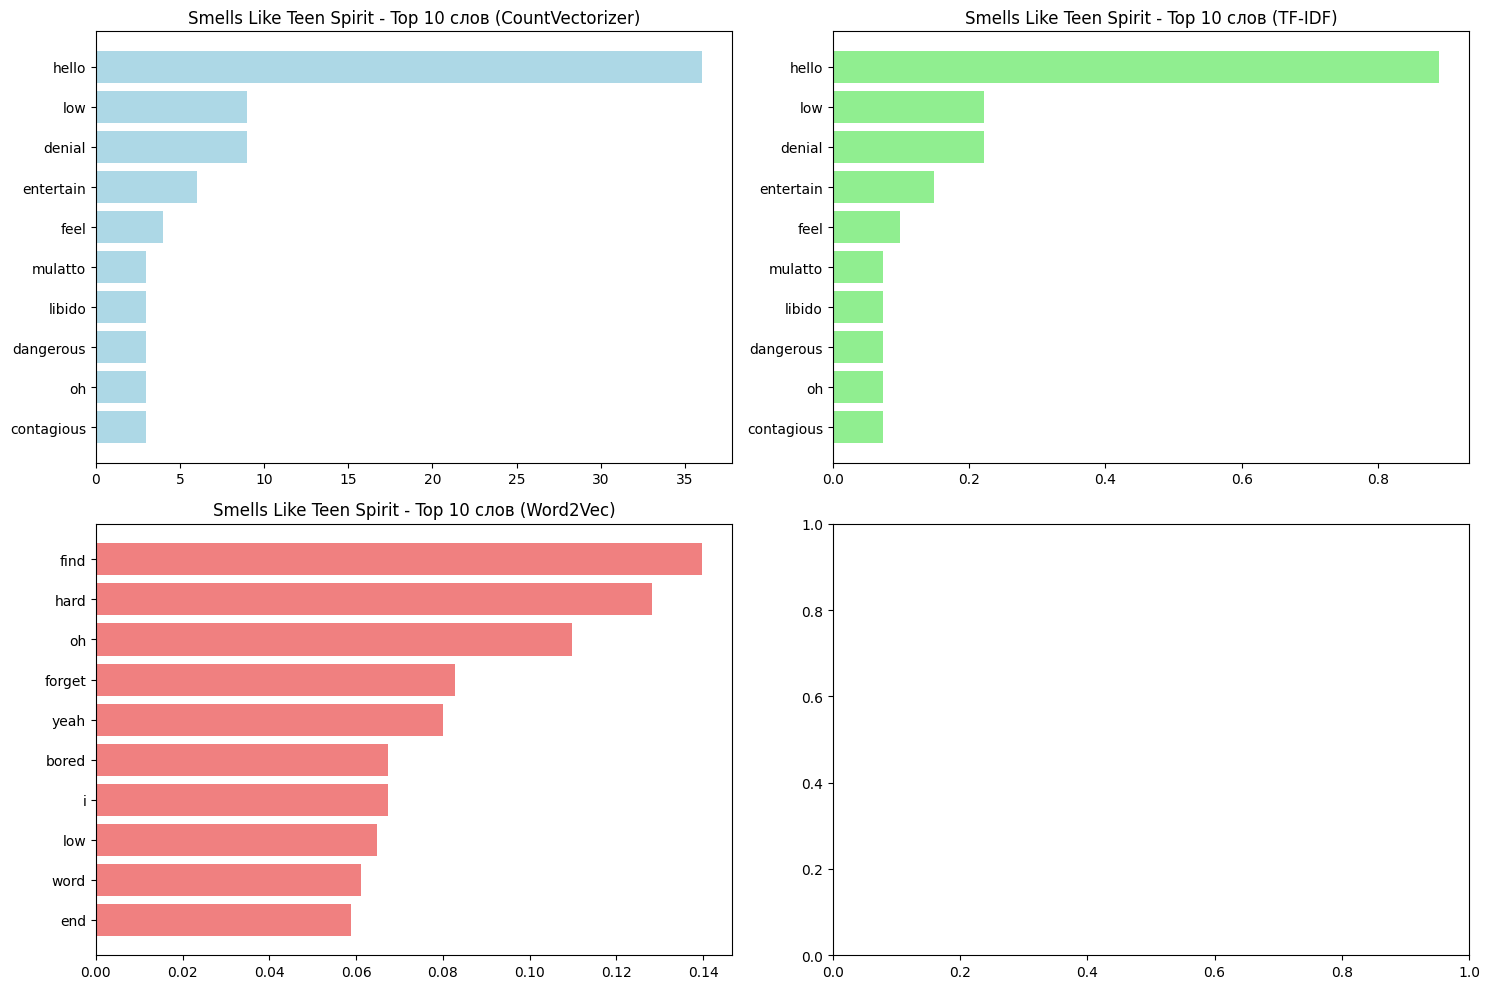

In [ ]:
# Функция для обработки текста с использованием CountVectorizer, TF-IDF, Word2Vec и Doc2Vec
def process_song(text):
    # Применение Count Vectorizer
    count_vectorizer = CountVectorizer()
    count_vectorizer_matrix = count_vectorizer.fit_transform([text])
    count_vectorizer_terms = count_vectorizer.get_feature_names_out()
    count_vectorizer_top_10 = pd.Series(count_vectorizer_matrix.toarray().flatten(), index=count_vectorizer_terms).sort_values(ascending=False).head(10)

    # Применение TF-IDF Vectorizer
    tfidf_vectorizer = TfidfVectorizer()
    tfidf_matrix = tfidf_vectorizer.fit_transform([text])
    tfidf_terms = tfidf_vectorizer.get_feature_names_out()
    tfidf_top_10 = pd.Series(tfidf_matrix.toarray().flatten(), index=tfidf_terms).sort_values(ascending=False).head(10)

    # Применение Word2Vec
    tokenized_text = [token.text.lower() for token in nlp(text) if token.is_alpha]
    word2vec_model = Word2Vec([tokenized_text], vector_size=100, window=5, min_count=1, workers=4)

    # Суммируем векторы для каждого слова и сортируем по значению
    word2vec_words = word2vec_model.wv.index_to_key
    word2vec_word_vecs = np.array([word2vec_model.wv[word] for word in word2vec_words])
    word2vec_word_sums = np.sum(word2vec_word_vecs, axis=1)
    word2vec_top_10 = pd.Series(word2vec_word_sums, index=word2vec_words).sort_values(ascending=False).head(10)


    return {
        "count_vectorizer_top_10": count_vectorizer_top_10,
        "tfidf_top_10": tfidf_top_10,
        "word2vec_top_10": word2vec_top_10
    }


# Применяем функцию к каждой песне
let_it_be_results = process_song(processed_texts[0])
jingle_bells_results = process_song(processed_texts[1])
smells_like_teen_spirit_results = process_song(processed_texts[2])

def display_results(song_name, results):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # CountVectorizer
    axes[0, 0].barh(results["count_vectorizer_top_10"].index, results["count_vectorizer_top_10"].values, color='lightblue')
    axes[0, 0].set_title(f'{song_name} - Top 10 слов (CountVectorizer)')
    axes[0, 0].invert_yaxis()

    # TF-IDF
    axes[0, 1].barh(results["tfidf_top_10"].index, results["tfidf_top_10"].values, color='lightgreen')
    axes[0, 1].set_title(f'{song_name} - Top 10 слов (TF-IDF)')
    axes[0, 1].invert_yaxis()

    # Word2Vec
    axes[1, 0].barh(results["word2vec_top_10"].index, results["word2vec_top_10"].values, color='lightcoral')
    axes[1, 0].set_title(f'{song_name} - Top 10 слов (Word2Vec)')
    axes[1, 0].invert_yaxis()

    plt.tight_layout()
    plt.show()

display_results("Let It Be", let_it_be_results)
display_results("Jingle Bells", jingle_bells_results)
display_results("Smells Like Teen Spirit", smells_like_teen_spirit_results)

# Сравнение методов: TF-IDF, Count Vectorizer, Word2Vec и Doc2Vec

## 1. **TF-IDF (Term Frequency-Inverse Document Frequency)**

**Как работает:**
- **TF-IDF** оценивает важность каждого слова в контексте документа, учитывая его частоту в других документах. Это помогает уменьшить важность часто встречающихся слов (например, стоп-слов).

**Преимущества:**
- Легко масштабируется для обработки большого объёма данных, так как каждый документ представляется в виде вектора с статистикой по терминам.
- Быстрый и эффективный алгоритм, не требующий сложных вычислений или обучающих наборов данных.

**Недостатки:**
- Не учитывает контекст или семантику слов (например, различные формы слова воспринимаются как отдельные термины).
- Не подходит для задач, связанных с обработкой текста, где важна семантика (например, в задачах перевода, распознавания сущностей и т. д.).

**Использование в масштабах:**
- Хорошо работает с большими объёмами данных (например, с текстами на 10 тысяч или больше документов).
- Может быть менее эффективным при обработке огромных данных (например, вики-корпус), так как необходимо хранить большое количество признаков для каждого документа.


## 2. **Count Vectorizer**

**Как работает:**
- **Count Vectorizer** создает вектор, который просто подсчитывает количество появления каждого слова в документе. Это самый базовый метод представления текста в виде числового вектора.
- Метод строит матрицу, где строки — это документы, а столбцы — уникальные слова из всех документов.

**Преимущества:**
- Прост в реализации и достаточно быстрый.
- Хорошо работает для простых задач, где важно только количество упоминаний слов, а не их контекст.

**Недостатки:**
- Как и TF-IDF, не учитывает порядок или контекст слов.
- Также игнорирует семантические связи и может создавать очень большие векторы, что делает его менее эффективным для масштабируемости.

**Использование на больших данных:**
- Подходит для задач с небольшим или средним объёмом данных, так как при увеличении объема данных требуемая память может расти экспоненциально.


## 3. **Word2Vec**

**Как работает:**
- **Word2Vec** обучает плотные векторные представления для слов с использованием нейронных сетей. Это позволяет каждому слову быть представлено в виде вектора, который захватывает семантику и контекст.
- Пример: слова, имеющие схожее значение (например, "король" и "королева"), будут иметь похожие векторные представления.

**Преимущества:**
- Учитывает контекст слов, что позволяет получать более точные и осмысленные векторные представления.
- Эффективен в задачах, где важна семантика, например, в анализе смысловых связей между словами.

**Недостатки:**
- Требует значительных вычислительных ресурсов и времени для обучения модели, особенно при большом объёме данных.
- Не подходит для задач, где необходимо обработать много текстов с малым количеством данных (например, с редкими словами).

**Использование на больших данных:**
- Хорошо масштабируется, но требует достаточно мощных вычислительных ресурсов (например, для обучения модели на большом наборе данных).
- Для очень больших данных, например, для глобальных корпусов текста, может потребоваться распределённое обучение.


## 4. **Doc2Vec (в данной работе не используется)**

**Как работает:**
- **Doc2Vec** — это расширение Word2Vec, которое обучает векторные представления для целых документов, а не отдельных слов. Это позволяет представить документы в виде плотных векторов, которые могут быть использованы для различных задач, таких как классификация и кластеризация.

**Преимущества:**
- Учитывает не только слова в тексте, но и их порядок и контекст в рамках документа.
- Отлично подходит для задач, где необходимо анализировать длинные тексты или несколько связанных предложений.

**Недостатки:**
- Требует значительных вычислительных ресурсов для обучения на больших наборах данных.
- Не всегда даёт лучшие результаты по сравнению с более простыми подходами, такими как TF-IDF, в задачах с короткими текстами.

**Использование на больших данных:**
- Масштабируем, но также требует много ресурсов для обучения. Для очень больших текстовых коллекций может понадобиться использование распределённого обучения.


## **Сравнение методов по вычислительной эффективности и масштабируемости**

| Метод              | Вычислительная эффективность | Масштабируемость    | Преимущества                           | Недостатки                           |
|--------------------|------------------------------|---------------------|----------------------------------------|--------------------------------------|
| **TF-IDF**         | Высокая                       | Высокая             | Легко масштабируется, быстрый расчёт   | Игнорирует контекст, не всегда точен |
| **Count Vectorizer** | Высокая                       | Средняя             | Простой и быстрый для малых наборов    | Не учитывает контекст, большие векторы |
| **Word2Vec**       | Низкая (требует обучающих данных) | Средняя (зависит от мощности) | Учитывает контекст и семантику | Требует обучения, высокие вычислительные затраты |
| **Doc2Vec**        | Низкая (требует обучения)    | Средняя (зависит от мощности) | Учёт контекста и структуры документа  | Высокие требования к вычислениям |

Теперь применим методы к трем песням вместе

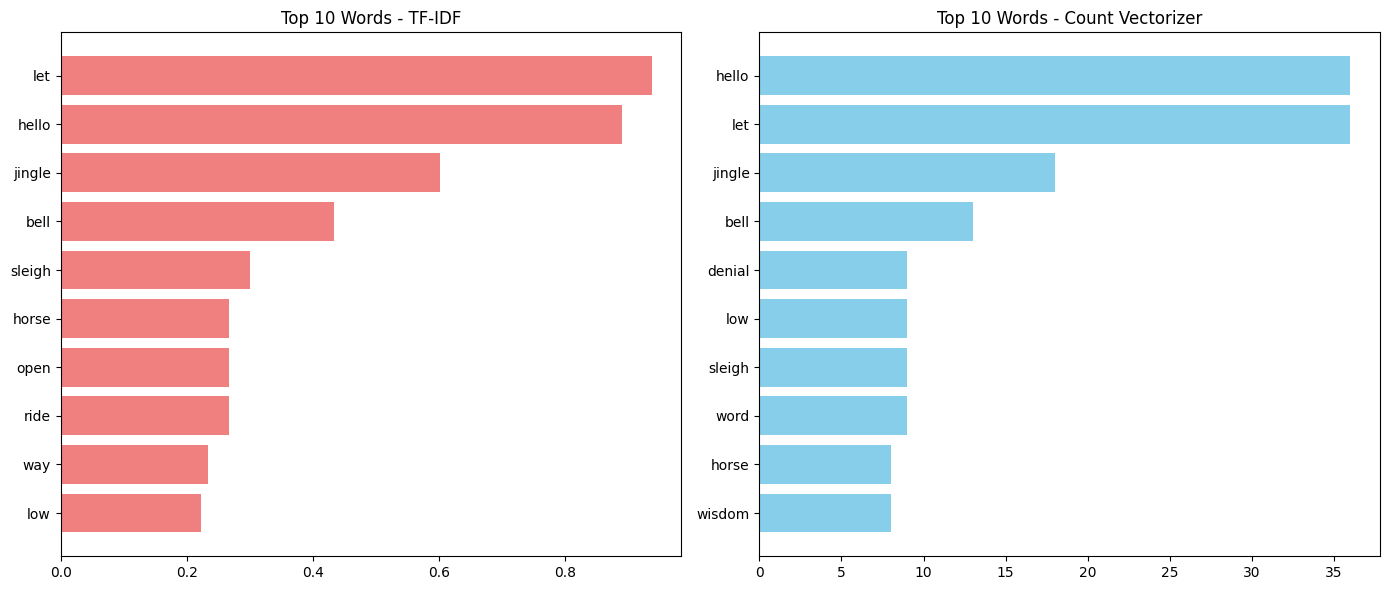

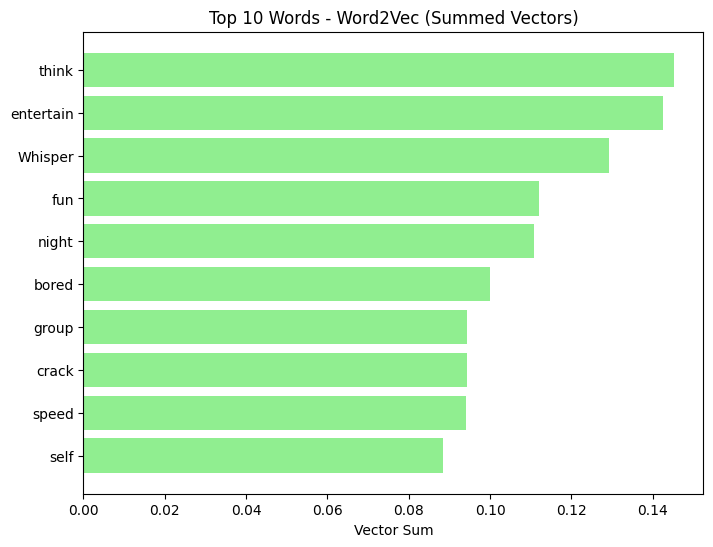

In [ ]:
# **TF-IDF**
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(processed_texts)
tfidf_terms = tfidf_vectorizer.get_feature_names_out()
tfidf_values = tfidf_matrix.toarray()

# **Count Vectorizer**
count_vectorizer = CountVectorizer()
count_matrix = count_vectorizer.fit_transform(processed_texts)
count_terms = count_vectorizer.get_feature_names_out()
count_values = count_matrix.toarray()
count_df = pd.DataFrame(count_values, columns=count_terms)

# **Word2Vec**
tokenized_texts = [[token.lemma_ for token in nlp(text) if token.is_alpha and not token.is_stop] for text in texts]
word2vec_model = Word2Vec(sentences=tokenized_texts, vector_size=100, window=5, min_count=1, workers=4)
word2vec_vectors = {word: word2vec_model.wv[word] for word in word2vec_model.wv.index_to_key}

# Визуализация TF-IDF и Count Vectorizer
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_tfidf = tfidf_df.sum().sort_values(ascending=False).head(10)
axes[0].barh(top_tfidf.index, top_tfidf.values, color='lightcoral')
axes[0].set_title("Top 10 Words - TF-IDF")
axes[0].invert_yaxis()

top_count = count_df.sum().sort_values(ascending=False).head(10)
axes[1].barh(top_count.index, top_count.values, color='skyblue')
axes[1].set_title("Top 10 Words - Count Vectorizer")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

word2vec_sums = {word: np.sum(vec) for word, vec in word2vec_vectors.items()}
top_word2vec = pd.Series(word2vec_sums).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_word2vec.index, top_word2vec.values, color='lightgreen')
plt.title("Top 10 Words - Word2Vec (Summed Vectors)")
plt.xlabel("Vector Sum")
plt.gca().invert_yaxis()
plt.show()

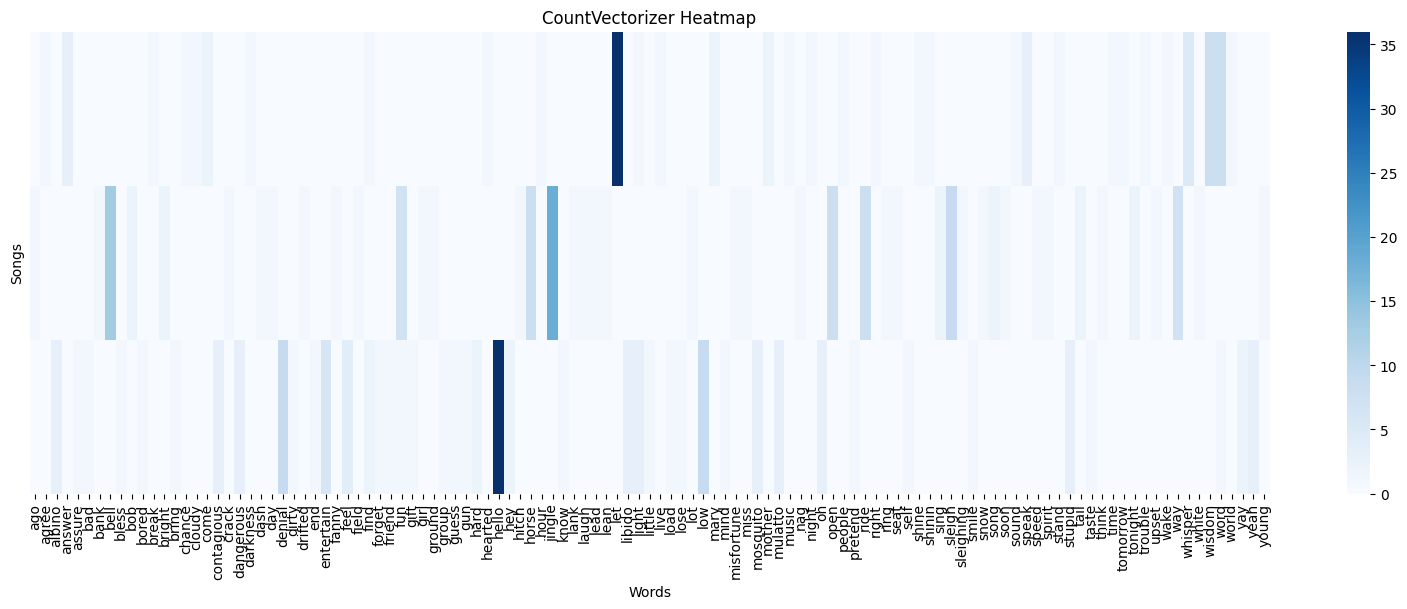

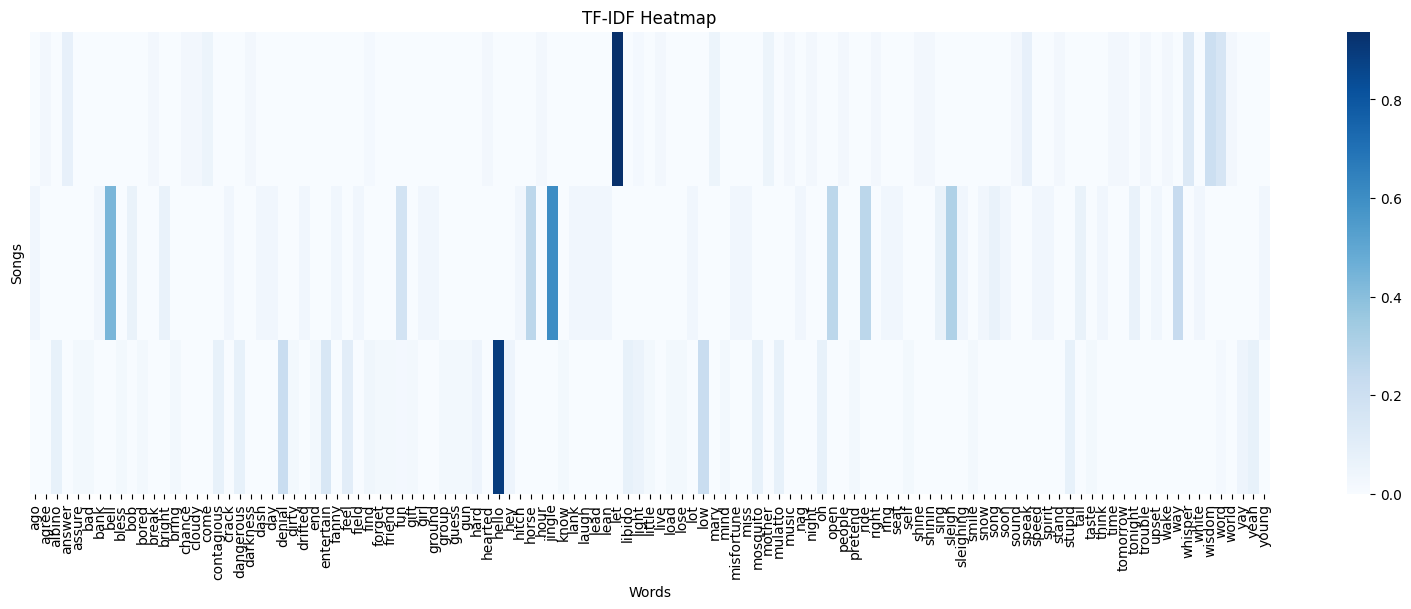

In [ ]:
# Построим тепловые карты для CountVectorizer и TF-IDF
def plot_heatmap(matrix, terms, title):
    plt.figure(figsize=(20, 6))
    sns.heatmap(matrix, cmap="Blues", xticklabels=terms, yticklabels=False, cbar=True)
    plt.title(title)
    plt.xlabel("Words")
    plt.ylabel("Songs")
    plt.show()

plot_heatmap(count_matrix.toarray(), count_terms, "CountVectorizer Heatmap")
plot_heatmap(tfidf_matrix.toarray(), tfidf_terms, "TF-IDF Heatmap")

Построим облако слов

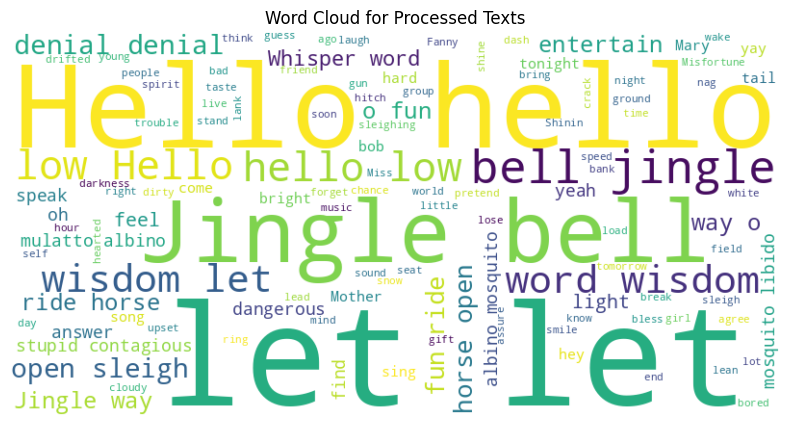

In [ ]:
all_text = " ".join(processed_texts)

# Облако слов
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Processed Texts")
plt.show()

### **Исследование частотности слов и словосочетаний по данным CountVectorizer, TF-IDF и Word2Vec**

## **1. "Let It Be"**  
**Наиболее частые слова (CountVectorizer):**  
- **let** (36)  
- **word** (8)  
- **wisdom** (8)  
- **whisper** (5)  
- **speak** (3)  
- **answer** (3)  

**Наиболее важные слова (TF-IDF):**  
- **let** (0.928)  
- **word** (0.206)  
- **wisdom** (0.206)  
- **whisper** (0.129)  
- **speak** (0.077)  

**Наиболее значимые слова (Word2Vec):**  
- **music** (0.140)  
- **sound** (0.128)  
- **hour** (0.110)  
- **chance** (0.083)  
- **darkness** (0.080)  

## **2. "Jingle Bells"**  
**Наиболее частые слова (CountVectorizer):**  
- **jingle** (18)  
- **bell** (13)  
- **sleigh** (9)  
- **ride** (8)  
- **horse** (8)  

**Наиболее важные слова (TF-IDF):**  
- **jingle** (0.594)  
- **bell** (0.429)  
- **sleigh** (0.297)  
- **ride** (0.264)  
- **horse** (0.264)  

**Наиболее значимые слова (Word2Vec):**  
- **ring** (0.140)  
- **sleighing** (0.128)  
- **sing** (0.110)  
- **crack** (0.082)  
- **tail** (0.080)  


## **3. "Smells Like Teen Spirit"**  
**Наиболее частые слова (CountVectorizer):**  
- **hello** (36)  
- **low** (9)  
- **denial** (9)  
- **entertain** (6)  
- **feel** (4)  

**Наиболее важные слова (TF-IDF):**  
- **hello** (0.888)  
- **low** (0.222)  
- **denial** (0.222)  
- **entertain** (0.148)  
- **feel** (0.098)  

**Наиболее значимые слова (Word2Vec):**  
- **yay** (0.140)  
- **hard** (0.128)  
- **mosquito** (0.110)  
- **lose** (0.082)  
- **libido** (0.080)  

## **Общий вывод**
### **Наиболее частые слова во всех песнях (CountVectorizer):**
- **"let"** (36) в *Let It Be*
- **"hello"** (36) в *Smells Like Teen Spirit*
- **"jingle"** (18) в *Jingle Bells*

### **Наиболее важные слова (TF-IDF):**
- **"let"** (0.928) в *Let It Be*
- **"hello"** (0.888) в *Smells Like Teen Spirit*
- **"jingle"** (0.594) в *Jingle Bells*

### **Наиболее значимые слова по Word2Vec:**
- **"music"** в *Let It Be* (0.140)
- **"ring"** в *Jingle Bells* (0.140)
- **"yay"** в *Smells Like Teen Spirit* (0.140)


### **Итоговое заключение**
- **CountVectorizer** выделяет просто частотные слова.
- **TF-IDF** показывает, какие слова действительно важны в тексте.
- **Word2Vec** дает представление о контексте и смысле слов.

# Часть 2

In [ ]:
# Путь к файлу датасета
file_path = "/kaggle/input/imdb-dataset-1/IMDB Dataset.csv"
df = pd.read_csv(file_path)
print(df.head())
df.info()
df.describe()

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [ ]:
df = df.drop_duplicates().dropna().reset_index(drop=True)
df["sentiment"].replace({"positive": 1, "negative": 0}, inplace = True)

def re_process(text):
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r"[^\w\s.,!?]", "", text)
    return text

df['review'] = df['review'].apply(re_process)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_texts, test_texts, train_labels, test_labels = train_test_split(df["review"], df["sentiment"], test_size=0.2, random_state=42, stratify=df["sentiment"])

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
train_encodings = tokenizer(list(train_texts), padding="max_length", truncation=True, max_length=64)
test_encodings = tokenizer(list(test_texts), padding="max_length", truncation=True, max_length=64)

class MyDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = MyDataset(train_encodings, train_labels.values)
test_dataset = MyDataset(test_encodings, test_labels.values)

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    hidden_dropout_prob=0.35,
    attention_probs_dropout_prob=0.3
)
model.to(device)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    logging_dir="./logs",
    report_to="none")


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,)

epochs = training_args.num_train_epochs
for epoch in range(int(epochs)):
    print(f"Epoch {epoch + 1}/{int(epochs)}")
    with tqdm(total=len(train_dataset) // training_args.per_device_train_batch_size) as pbar:
        trainer.train()
        pbar.update(1)

metrics = trainer.evaluate()

<ipython-input-10-130affc45f07>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["sentiment"].replace({"positive": 1, "negative": 0}, inplace = True)
<ipython-input-10-130affc45f07>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["sentiment"].replace({"positive": 1, "negative": 0}, inplace = 

Using device: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

/usr/local/lib/python3.10/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
  0%|          | 1/4958 [19:19<1596:04:56, 1159.15s/it]


Epoch 2/2


  0%|          | 0/4958 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.618700,0.598296
2,0.502100,0.511597


/usr/local/lib/python3.10/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
  0%|          | 1/4958 [19:24<1603:14:23, 1164.35s/it]
/usr/local/lib/python3.10/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Подсчет итоговой точности. Если обучать на большем числе эпох и увеличить максимальную длину токенайзера, то качество модели повысится. Но сильно увеличивается время обучения.


In [ ]:
test_outputs = trainer.predict(test_dataset)
logit_scores = test_outputs.predictions
predicted_classes = np.argmax(torch.tensor(logit_scores), axis=1).numpy()
actual_classes = test_outputs.label_ids
accuracy_metric = evaluate.load("accuracy")
model_accuracy = accuracy_metric.compute(predictions=predicted_classes, references=actual_classes)
print(f"Final model Accuracy: {model_accuracy['accuracy']:.4f}")

Final model Accuracy: 0.7748


Протестируем на двух конкректных примерах отзывов (придумали сами, не из датасета, но у каждого понятна эмоциональная окраска)

In [ ]:
review_good = "This movie was truly a delight! The plot was captivating, the characters felt real, and the visuals were breathtaking."
review_bad = "This film was a huge disappointment. The story made no sense, the performances were lifeless, and I couldn't wait for it to end."

# Анализ тональности
def analyze_sentiment(text):
    encoded_text = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=64)
    encoded_text = {k: v.to(device) for k, v in encoded_text.items()}

    model.eval()
    with torch.no_grad():
        output = model(**encoded_text)
        sentiment_label = torch.argmax(output.logits, dim=1).item()

    return "Positive" if sentiment_label == 1 else "Negative"

print(f"Sentiment Analysis Result (Positive Review): {analyze_sentiment(review_good)}")
print(f"Sentiment Analysis Result (Negative Review): {analyze_sentiment(review_bad)}")

Sentiment Analysis Result (Positive Review): Positive
Sentiment Analysis Result (Negative Review): Negative
